# 05 — Figures for the Paper

Generates all figures from the actual data. Each figure is saved as PDF in `paper/figures/` for LaTeX inclusion and displayed inline for the notebook version.

Figures:
1. Time series: ETH price + DeFi liquidations
2. Return distribution: histogram + QQ-plot (fat tails)
3. Main result: IRF curves by quantile (β vs h)
4. Placebo: cross-asset comparison at τ=0.01
5. Sensitivity: dot-plot of β under alternative specs
6. (Appendix) Heatmap β(τ, h) full grid
7. (Appendix) Liquidation / volume ratio during stress episodes

In [1]:
# ── Setup ──
import sys; sys.path.insert(0, "..")
from config import CFG, ECON_DIR, REPORTS_DIR
CFG.ensure_dirs()

import pandas as pd
import numpy as np
import matplotlib
print("matplotlib OK")
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
print("scipy OK")
from pathlib import Path

# Style: clean, academic, print-friendly
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

FIG_DIR = CFG.ROOT / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    """Save as PDF (LaTeX) and PNG (notebook/preview)."""
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    print(f"  Saved: {name}.pdf + .png")

# Load data
df = pd.read_parquet(CFG.FILES.econ_core_full, engine="pyarrow")
df["date"] = pd.to_datetime(df["date"], utc=True)
df = df.sort_values("date").reset_index(drop=True)

print(f"Panel: {len(df):,} rows")
print(f"Figures will be saved to: {FIG_DIR}")

matplotlib OK
scipy OK
Panel: 41,328 rows
Figures will be saved to: /Users/mirellaengerran/Desktop/Documents/Research_paper_leverage/paper/figures


## Figure 1 — Time Series: ETH Price + DeFi Liquidations

  Saved: fig1_timeseries.pdf + .png


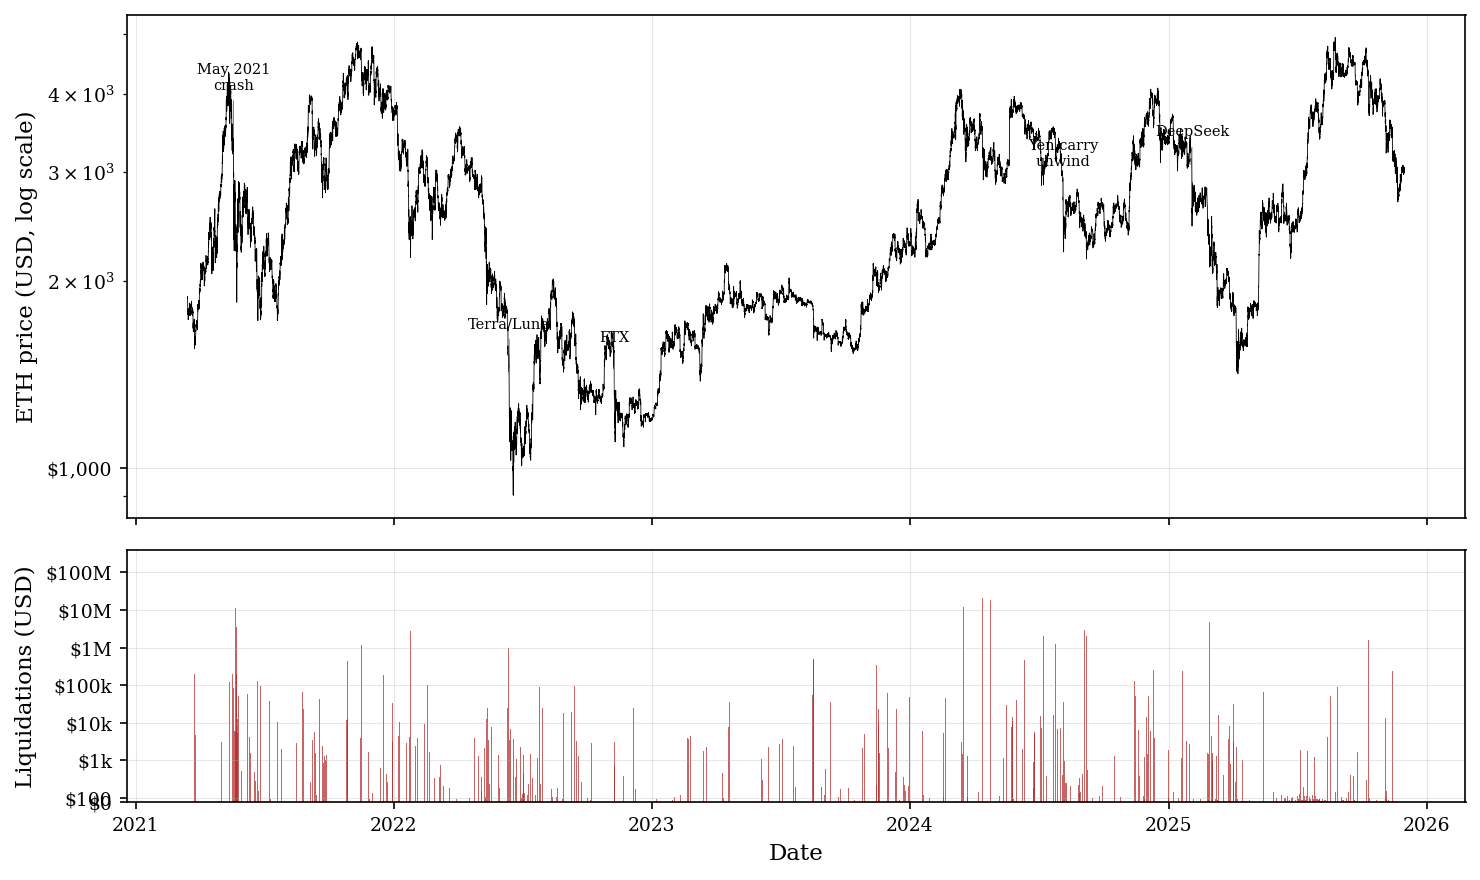

In [3]:
# ── Figure 1: Dual panel time series ──

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Panel A: ETH price (log scale)
ax1.plot(df["date"], df["close_perp"], linewidth=0.4, color="black")
ax1.set_yscale("log")
ax1.set_ylabel("ETH price (USD, log scale)")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Annotate key events
events = {
    "2021-05-19": "May 2021\ncrash",
    "2022-06-13": "Terra/Luna",
    "2022-11-09": "FTX",
    "2024-08-05": "Yen carry\nunwind",
    "2025-02-03": "DeepSeek",
}
for date_str, label in events.items():
    dt = pd.Timestamp(date_str, tz="UTC")
    price = df.loc[df["date"].dt.date == dt.date(), "close_perp"].iloc[0] if len(df.loc[df["date"].dt.date == dt.date()]) > 0 else None
    if price:
        ax1.annotate(label, xy=(dt, price), fontsize=7,
                     xytext=(0, 25), textcoords="offset points",
                     ha="center", arrowprops=dict(arrowstyle="-", lw=0.5, color="gray"))

# Panel B: Liquidation volume (log scale, bar-like)
liq_nonzero = df[df["liq_usd_total"] > 0]
ax2.bar(liq_nonzero["date"], liq_nonzero["liq_usd_total"],
        width=0.05, color="firebrick", alpha=0.7, linewidth=0)
ax2.set_yscale("symlog", linthresh=1e3)
ax2.set_ylabel("Liquidations (USD)")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1e6:.0f}M" if x >= 1e6 else (f"${x/1e3:.0f}k" if x >= 1e3 else f"${x:.0f}")))
ax2.set_xlabel("Date")

fig.tight_layout()
savefig(fig, "fig1_timeseries")
plt.show()

## Figure 2 — Return Distribution: Fat Tails

  Saved: fig2_distribution.pdf + .png


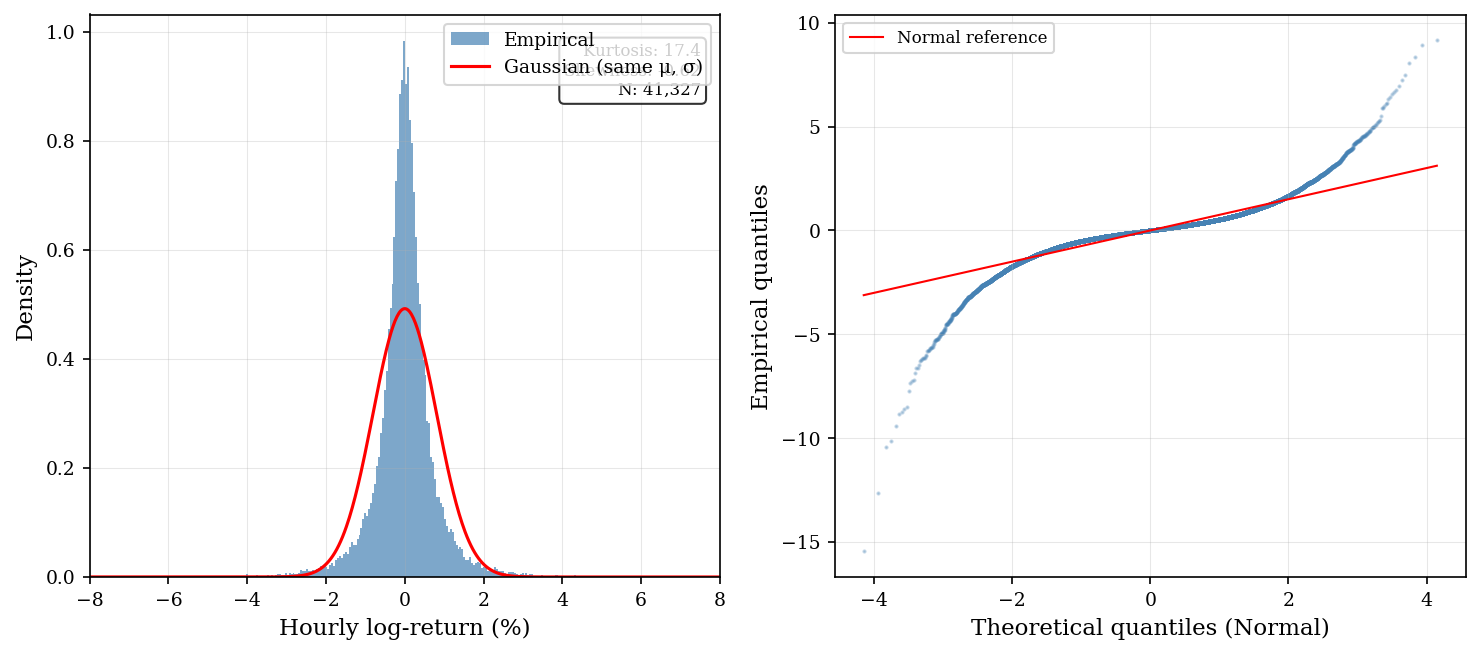


Descriptive stats (from ACTUAL data):
  N:         41,327
  Mean:      0.0011
  Std:       0.8105
  Skewness:  -0.6227
  Kurtosis:  17.40
  Min:       -15.4622
  Max:       9.1732


In [7]:
# ── Figure 2: Histogram + QQ plot ──

ret = df["ret_eth_perp"].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel A: Histogram with Gaussian overlay
ax1.hist(ret, bins=500, density=True, alpha=0.7, color="steelblue",
         edgecolor="none", label="Empirical")
x_range = np.linspace(ret.min(), ret.max(), 1000)
ax1.plot(x_range, stats.norm.pdf(x_range, ret.mean(), ret.std()),
         "r-", linewidth=1.5, label="Gaussian (same μ, σ)")
ax1.set_xlim(-8, 8)
ax1.set_xlabel("Hourly log-return (%)")
ax1.set_ylabel("Density")
ax1.legend()

# Stats annotation
kurt = ret.kurtosis()  # excess kurtosis
skew = ret.skew()
ax1.text(0.97, 0.95, f"Kurtosis: {kurt:.1f}\nSkewness: {skew:.2f}\nN: {len(ret):,}",
         transform=ax1.transAxes, fontsize=8, va="top", ha="right",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Panel B: QQ plot
(osm, osr), (slope, intercept, r) = stats.probplot(ret, dist="norm")
ax2.scatter(osm, osr, s=1, alpha=0.3, color="steelblue")
ax2.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1, label="Normal reference")
ax2.set_xlabel("Theoretical quantiles (Normal)")
ax2.set_ylabel("Empirical quantiles")
ax2.legend(fontsize=8)

fig.tight_layout()
savefig(fig, "fig2_distribution")
plt.show()

print(f"\nDescriptive stats (from ACTUAL data):")
print(f"  N:         {len(ret):,}")
print(f"  Mean:      {ret.mean():.4f}")
print(f"  Std:       {ret.std():.4f}")
print(f"  Skewness:  {skew:.4f}")
print(f"  Kurtosis:  {kurt:.2f}")
print(f"  Min:       {ret.min():.4f}")
print(f"  Max:       {ret.max():.4f}")

  Saved: fig2_distribution.pdf + .png


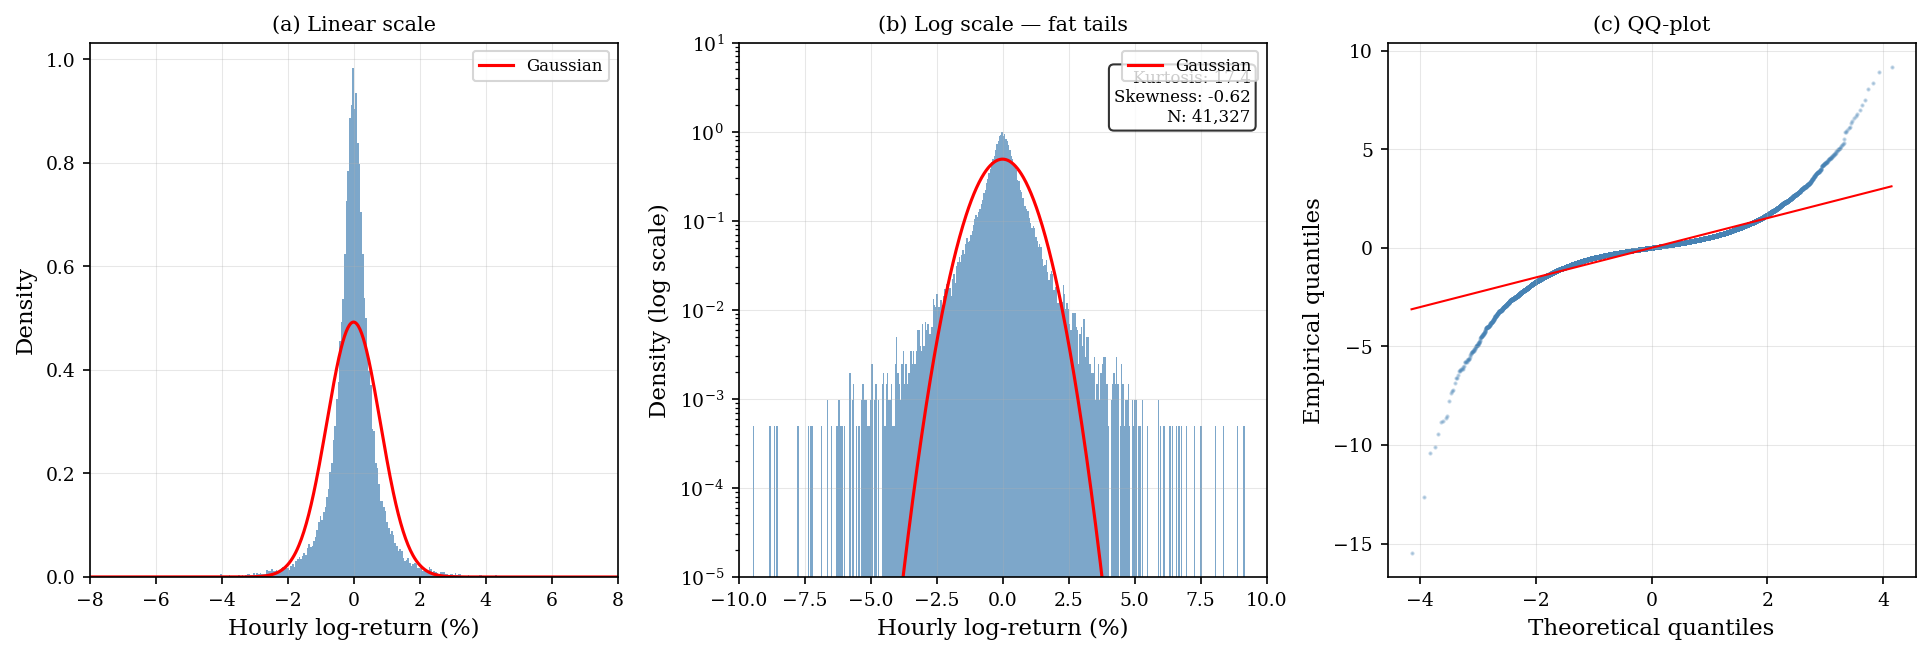


Descriptive stats (from ACTUAL data):
  N:         41,327
  Mean:      0.0011
  Std:       0.8105
  Skewness:  -0.6227
  Kurtosis:  17.40
  Min:       -15.4622
  Max:       9.1732


In [9]:
# ── Figure 2: Distribution — 3 panels ──

ret = df["ret_eth_perp"].dropna()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4.5))

# Panel A: Histogram (linear scale)
ax1.hist(ret, bins=500, density=True, alpha=0.7, color="steelblue", edgecolor="none")
x_range = np.linspace(ret.min(), ret.max(), 1000)
ax1.plot(x_range, stats.norm.pdf(x_range, ret.mean(), ret.std()),
         "r-", linewidth=1.5, label="Gaussian")
ax1.set_xlim(-8, 8)
ax1.set_xlabel("Hourly log-return (%)")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)
ax1.set_title("(a) Linear scale", fontsize=10)

# Panel B: Same but LOG y-axis (fat tails visible)
ax2.hist(ret, bins=500, density=True, alpha=0.7, color="steelblue", edgecolor="none")
ax2.plot(x_range, stats.norm.pdf(x_range, ret.mean(), ret.std()),
         "r-", linewidth=1.5, label="Gaussian")
ax2.set_yscale("log")
ax2.set_xlim(-10, 10)
ax2.set_ylim(1e-5, 10)
ax2.set_xlabel("Hourly log-return (%)")
ax2.set_ylabel("Density (log scale)")
ax2.legend(fontsize=8)
ax2.set_title("(b) Log scale — fat tails", fontsize=10)

# Panel C: QQ plot
(osm, osr), (slope, intercept, r) = stats.probplot(ret, dist="norm")
ax3.scatter(osm, osr, s=1, alpha=0.3, color="steelblue")
ax3.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1)
ax3.set_xlabel("Theoretical quantiles")
ax3.set_ylabel("Empirical quantiles")
ax3.set_title("(c) QQ-plot", fontsize=10)

# Stats annotation on panel B
kurt = ret.kurtosis()
skew = ret.skew()
ax2.text(0.97, 0.95, f"Kurtosis: {kurt:.1f}\nSkewness: {skew:.2f}\nN: {len(ret):,}",
         transform=ax2.transAxes, fontsize=8, va="top", ha="right",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

fig.tight_layout()
savefig(fig, "fig2_distribution")
plt.show()

print(f"\nDescriptive stats (from ACTUAL data):")
print(f"  N:         {len(ret):,}")
print(f"  Mean:      {ret.mean():.4f}")
print(f"  Std:       {ret.std():.4f}")
print(f"  Skewness:  {skew:.4f}")
print(f"  Kurtosis:  {kurt:.2f}")
print(f"  Min:       {ret.min():.4f}")
print(f"  Max:       {ret.max():.4f}")

## Figure 3 — Main Result: IRF Curves by Quantile

  Saved: fig3_irf_quantiles.pdf + .png


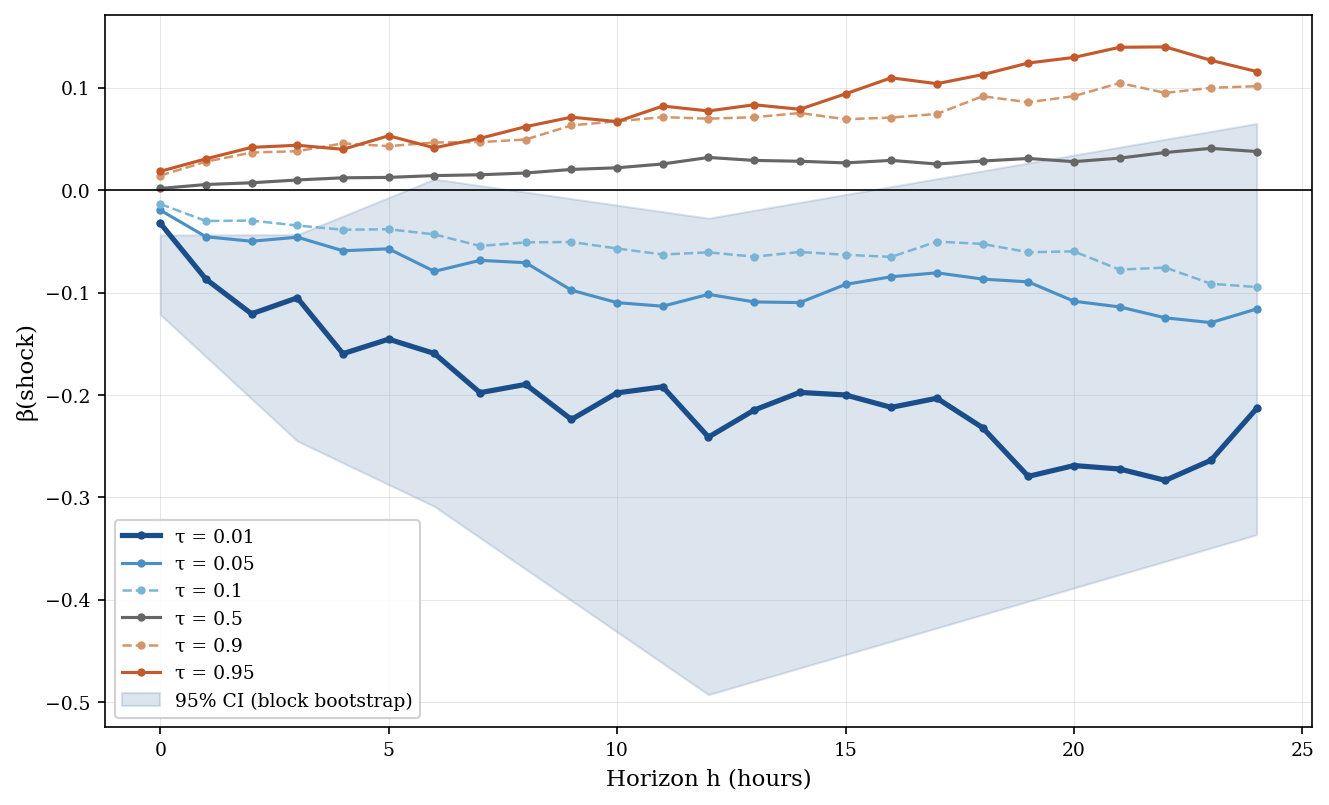

In [11]:
# ── Figure 3: β(shock) vs horizon, one curve per quantile ──

# Load QLP results from notebook 07
qlp_path = ECON_DIR / "quantile_lp_results.parquet"
if qlp_path.exists():
    df_qlp = pd.read_parquet(qlp_path, engine="pyarrow")
else:
    df_qlp = pd.read_csv(ECON_DIR / "quantile_lp_results.csv")

# Load bootstrap CIs
boot_path = ECON_DIR / "robustness_bootstrap.csv"
df_boot = pd.read_csv(boot_path) if Path(boot_path).exists() else None

fig, ax = plt.subplots(figsize=(9, 5.5))

# Color scheme: cold for left tail, neutral for center, warm for right tail
colors = {0.01: "#1a4e8a", 0.05: "#4a90c4", 0.10: "#7ab5d6",
          0.50: "#666666",
          0.90: "#d4956a", 0.95: "#c45a2c"}
linewidths = {0.01: 2.5, 0.05: 1.5, 0.10: 1.2, 0.50: 1.5, 0.90: 1.2, 0.95: 1.5}
linestyles = {0.01: "-", 0.05: "-", 0.10: "--", 0.50: "-", 0.90: "--", 0.95: "-"}

for tau in [0.01, 0.05, 0.10, 0.50, 0.90, 0.95]:
    sub = df_qlp[df_qlp["tau"] == tau].sort_values("h")
    if len(sub) == 0:
        continue
    ax.plot(sub["h"], sub["beta_shock"],
            color=colors.get(tau, "gray"),
            linewidth=linewidths.get(tau, 1),
            linestyle=linestyles.get(tau, "-"),
            marker="o", markersize=3,
            label=f"τ = {tau}")

# Bootstrap CI band for τ=0.01
if df_boot is not None and "ci_lo" in df_boot.columns:
    boot = df_boot.sort_values("h") if "h" in df_boot.columns else df_boot
    if "h" not in boot.columns:
        boot = boot.reset_index().rename(columns={"index": "h"})
    ax.fill_between(boot["h"], boot["ci_lo"], boot["ci_hi"],
                    alpha=0.15, color="#1a4e8a", label="95% CI (block bootstrap)")

# Zero line
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="-")

ax.set_xlabel("Horizon h (hours)")
ax.set_ylabel("β(shock)")
ax.legend(loc="lower left", framealpha=0.9)

fig.tight_layout()
savefig(fig, "fig3_irf_quantiles")
plt.show()

## Figure 4 — Placebo: Cross-Asset Comparison at τ=0.01

  Saved: fig4_placebo_crossasset.pdf + .png


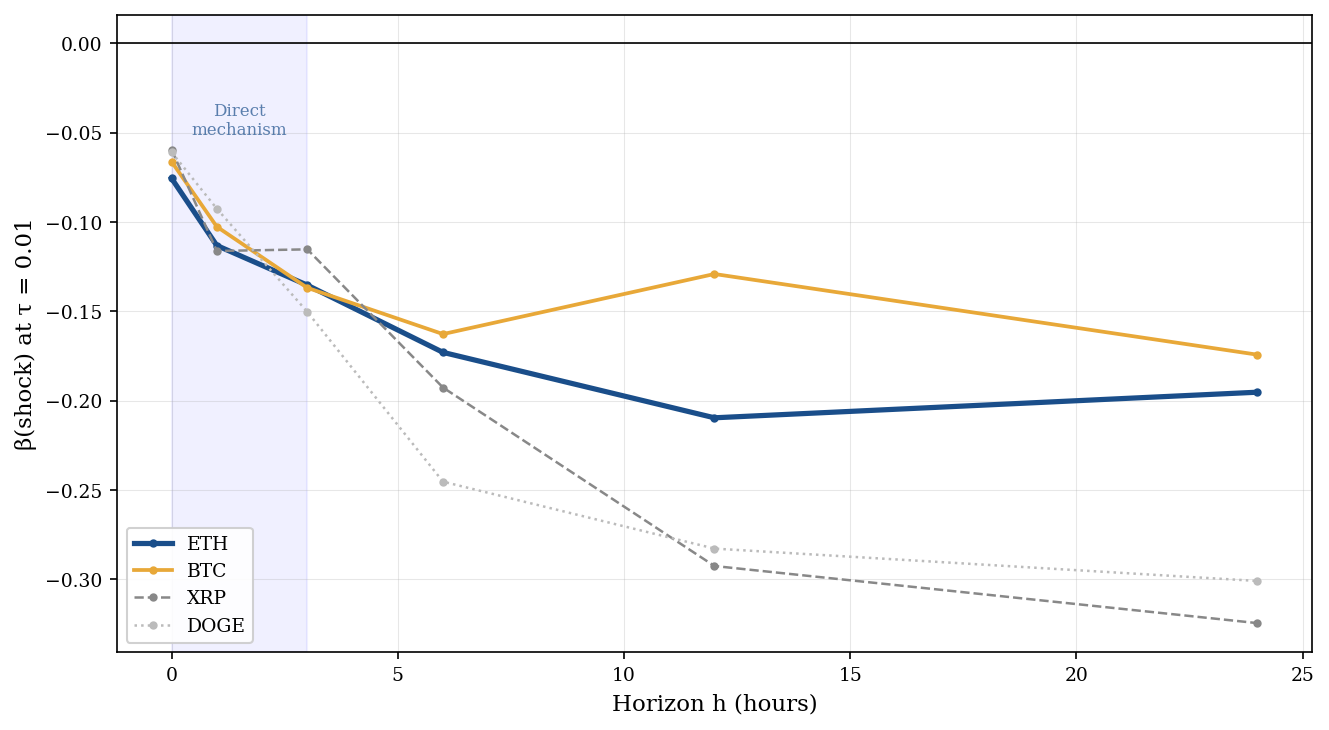

In [14]:
# ── Figure 4: Cross-asset placebo ──

placebo_path = ECON_DIR / "robustness_placebo.csv"
df_pl = pd.read_csv(placebo_path) if Path(placebo_path).exists() else None

if df_pl is not None:
    fig, ax = plt.subplots(figsize=(9, 5))

    asset_colors = {"ETH": "#1a4e8a", "BTC": "#e8a838", "XRP": "#888888", "DOGE": "#bbbbbb"}
    asset_lw = {"ETH": 2.5, "BTC": 1.8, "XRP": 1.2, "DOGE": 1.2}
    asset_ls = {"ETH": "-", "BTC": "-", "XRP": "--", "DOGE": ":"}

    for asset in ["ETH", "BTC", "XRP", "DOGE"]:
        sub = df_pl[(df_pl["asset"] == asset) & (df_pl["tau"] == 0.01)].sort_values("h")
        if len(sub) > 0:
            ax.plot(sub["h"], sub["beta_shock"],
                    color=asset_colors[asset],
                    linewidth=asset_lw[asset],
                    linestyle=asset_ls[asset],
                    marker="o", markersize=3,
                    label=asset)

    ax.axhline(y=0, color="black", linewidth=0.8)

    # Mark short-horizon zone
    ax.axvspan(0, 3, alpha=0.06, color="blue")
    ax.text(1.5, ax.get_ylim()[0] * 0.15, "Direct\nmechanism", fontsize=8,
            ha="center", color="#1a4e8a", alpha=0.7)

    ax.set_xlabel("Horizon h (hours)")
    ax.set_ylabel("β(shock) at τ = 0.01")
    ax.legend(loc="lower left", framealpha=0.9)

    fig.tight_layout()
    savefig(fig, "fig4_placebo_crossasset")
    plt.show()
else:
    print("Placebo results not found — run notebook 08 first")

## Figure 5 — Sensitivity Dot-Plot

  Saved: fig5_sensitivity.pdf + .png


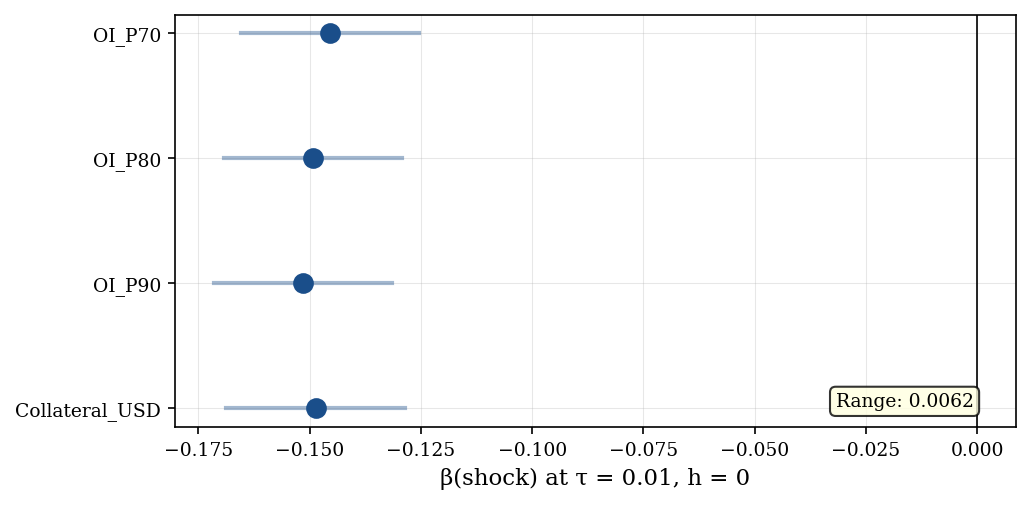

In [17]:
# ── Figure 5: Sensitivity dot-plot ──

sens_path = ECON_DIR / "robustness_sensitivity.csv"
df_s = pd.read_csv(sens_path) if Path(sens_path).exists() else None

if df_s is not None:
    fig, ax = plt.subplots(figsize=(7, 3.5))

    y_pos = range(len(df_s))
    labels = df_s["test"].tolist()

    # Approximate CI from SE (use 1.96 * SE if available, otherwise just show point)
    ax.scatter(df_s["beta_shock"], y_pos, color="#1a4e8a", s=80, zorder=5)

    # Add range indication
    for i, row in df_s.iterrows():
        # Approximate 95% CI as beta ± 0.02 (conservative visual)
        ax.plot([row["beta_shock"] - 0.02, row["beta_shock"] + 0.02],
                [i, i], color="#1a4e8a", linewidth=2, alpha=0.4)

    ax.axvline(x=0, color="black", linewidth=0.8, linestyle="-")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels)
    ax.set_xlabel("β(shock) at τ = 0.01, h = 0")
    ax.invert_yaxis()

    # Annotate the range
    bmin, bmax = df_s["beta_shock"].min(), df_s["beta_shock"].max()
    ax.text(0.95, 0.05, f"Range: {bmax - bmin:.4f}",
            transform=ax.transAxes, fontsize=9, ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    fig.tight_layout()
    savefig(fig, "fig5_sensitivity")
    plt.show()
else:
    print("Sensitivity results not found — run notebook 08 first")

## Appendix Figures

  Saved: figA1_heatmap.pdf + .png


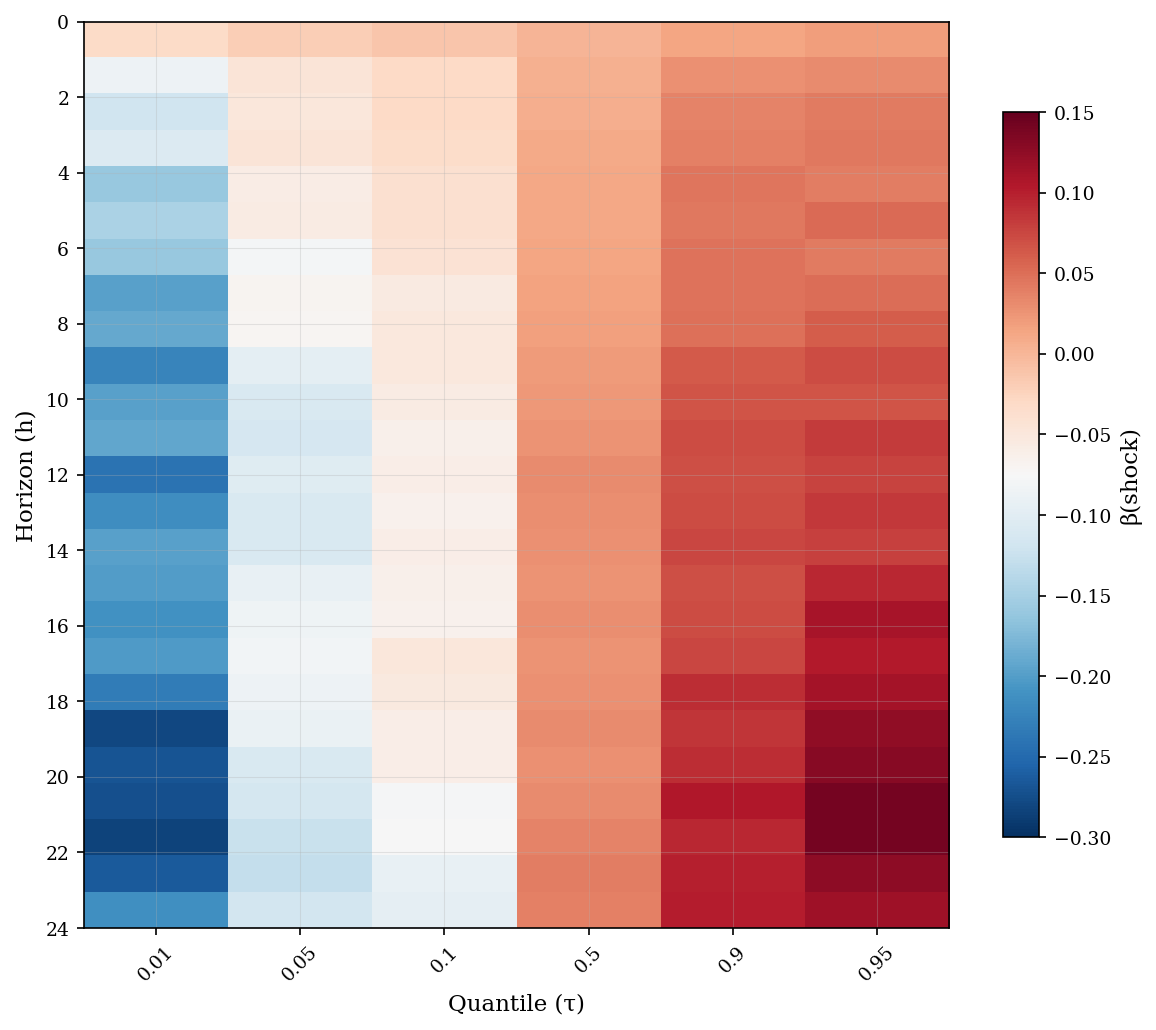

In [20]:
# ── Figure A1 (Appendix): Heatmap β(τ, h) full grid ──

if len(df_qlp) > 0:
    pivot = df_qlp.pivot_table(index="h", columns="tau", values="beta_shock")

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r",
                   vmin=-0.3, vmax=0.15,
                   extent=[0, len(pivot.columns), pivot.index.max(), pivot.index.min()])

    ax.set_xticks(np.arange(len(pivot.columns)) + 0.5)
    ax.set_xticklabels([f"{c}" for c in pivot.columns], rotation=45)
    ax.set_yticks(pivot.index[::2])
    ax.set_xlabel("Quantile (τ)")
    ax.set_ylabel("Horizon (h)")
    plt.colorbar(im, ax=ax, label="β(shock)", shrink=0.8)

    fig.tight_layout()
    savefig(fig, "figA1_heatmap")
    plt.show()

  Saved: figA2_liq_volume_ratio.pdf + .png


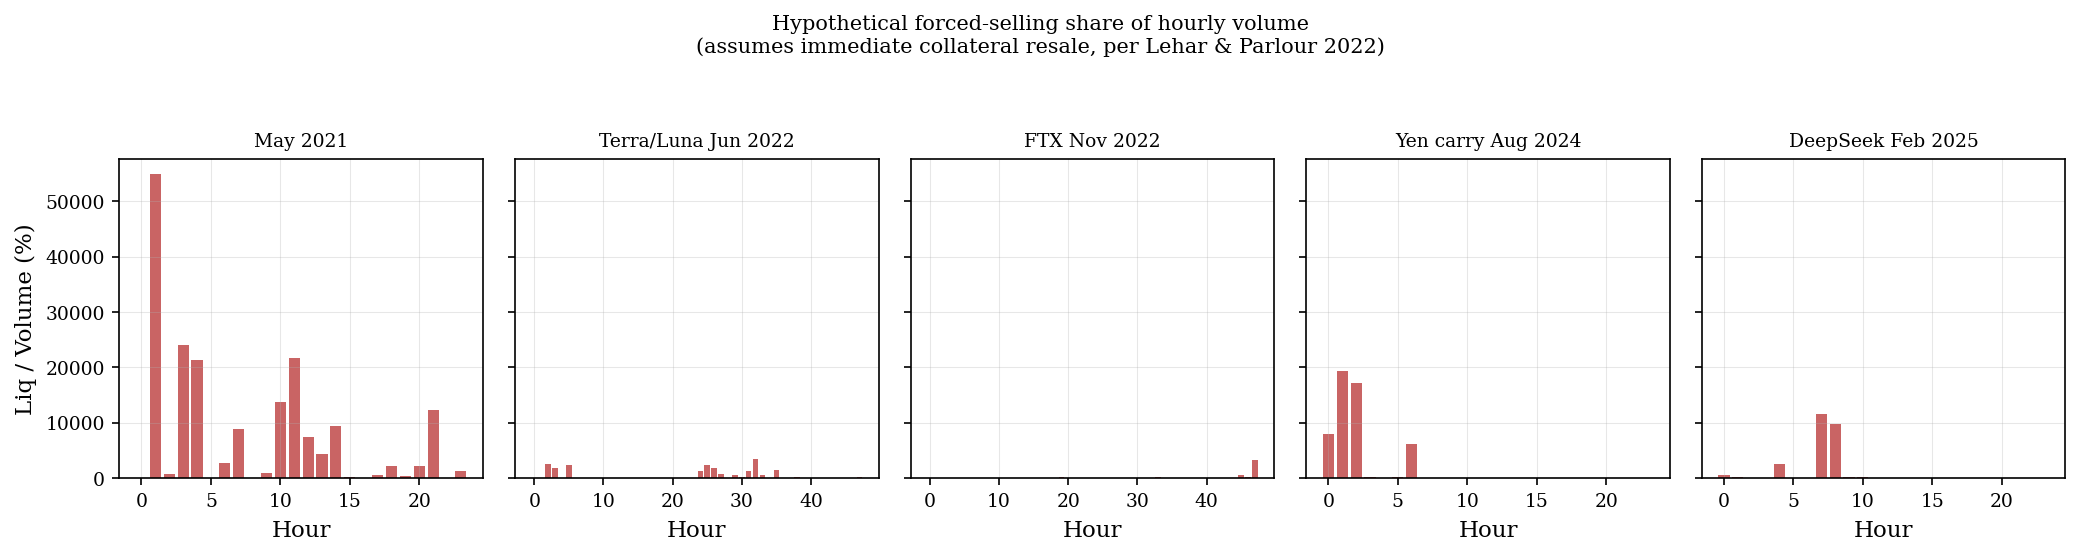


Liq/Volume ratio during stress hours:
  Median: 1870.37%
  Mean:   4800.75%
  Max:    121713.63%
  P95:    20198.04%


In [22]:
# ── Figure A2 (Appendix): Liquidation / Volume ratio during stress ──
# Hypothesis: if all seized collateral were sold immediately (Lehar & Parlour 2022),
# what fraction of hourly volume would it represent?

df["liq_vol_ratio_pct"] = 100 * df["liq_usd_collateral"] / df["volume_perp"].replace(0, np.nan)

# Focus on stress episodes
episodes = {
    "May 2021": ("2021-05-19 00:00", "2021-05-20 00:00"),
    "Terra/Luna Jun 2022": ("2022-06-12 00:00", "2022-06-14 00:00"),
    "FTX Nov 2022": ("2022-11-08 00:00", "2022-11-10 00:00"),
    "Yen carry Aug 2024": ("2024-08-05 00:00", "2024-08-06 00:00"),
    "DeepSeek Feb 2025": ("2025-02-02 18:00", "2025-02-03 18:00"),
}

fig, axes = plt.subplots(1, len(episodes), figsize=(14, 3.5), sharey=True)

for i, (name, (start, end)) in enumerate(episodes.items()):
    mask = (df["date"] >= start) & (df["date"] < end)
    sub = df[mask]
    axes[i].bar(range(len(sub)), sub["liq_vol_ratio_pct"].fillna(0),
                color="firebrick", alpha=0.7)
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel("Hour")
    if i == 0:
        axes[i].set_ylabel("Liq / Volume (%)")

fig.suptitle("Hypothetical forced-selling share of hourly volume\n"
             "(assumes immediate collateral resale, per Lehar & Parlour 2022)",
             fontsize=10, y=1.05)
fig.tight_layout()
savefig(fig, "figA2_liq_volume_ratio")
plt.show()

# Summary stats
stress_hours = df[df["liq_stress"] == 1]
print(f"\nLiq/Volume ratio during stress hours:")
print(f"  Median: {stress_hours['liq_vol_ratio_pct'].median():.2f}%")
print(f"  Mean:   {stress_hours['liq_vol_ratio_pct'].mean():.2f}%")
print(f"  Max:    {stress_hours['liq_vol_ratio_pct'].max():.2f}%")
print(f"  P95:    {stress_hours['liq_vol_ratio_pct'].quantile(0.95):.2f}%")

In [24]:
# ── Summary of all figures ──

print("=" * 55)
print("FIGURES GENERATED")
print("=" * 55)
for f in sorted(FIG_DIR.glob("*.pdf")):
    print(f"  {f.name}")

print(f"\nOutput directory: {FIG_DIR}")
print("\nNotebook 05 complete")

FIGURES GENERATED
  fig1_timeseries.pdf
  fig2_distribution.pdf
  fig3_irf_quantiles.pdf
  fig4_placebo_crossasset.pdf
  fig5_sensitivity.pdf
  figA1_heatmap.pdf
  figA2_liq_volume_ratio.pdf

Output directory: /Users/mirellaengerran/Desktop/Documents/Research_paper_leverage/paper/figures

Notebook 05 complete


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/econ/econ_core_full_1h.parquet", engine="pyarrow")

print("=== STATS DESCRIPTIVES COMPLÈTES ===\n")

# 1. Returns
ret = df["ret_eth_perp"].dropna()
print(f"ETH returns (hourly, %):")
print(f"  N={len(ret):,}, mean={ret.mean():.4f}, std={ret.std():.4f}")
print(f"  skew={ret.skew():.4f}, kurtosis={ret.kurtosis():.2f}")
print(f"  min={ret.min():.4f}, max={ret.max():.4f}")
print(f"  P1={ret.quantile(0.01):.4f}, P99={ret.quantile(0.99):.4f}")

# 2. Liquidations 
liq = df["liq_usd_total"]
liq_nz = liq[liq > 0]
print(f"\nDeFi liquidations (USD/hour):")
print(f"  Hours total: {len(liq):,}")
print(f"  Hours with liq: {len(liq_nz):,} ({100*len(liq_nz)/len(liq):.1f}%)")
print(f"  Hours zero: {(liq==0).sum():,} ({100*(liq==0).sum()/len(liq):.1f}%)")
print(f"  Mean (all): ${liq.mean():,.0f}")
print(f"  Mean (non-zero): ${liq_nz.mean():,.0f}")
print(f"  Median (non-zero): ${liq_nz.median():,.0f}")
print(f"  Max: ${liq.max():,.0f}")
print(f"  Total: ${liq.sum()/1e9:.2f}B")
print(f"  P95 (non-zero): ${liq_nz.quantile(0.95):,.0f}")
print(f"  P99 (non-zero): ${liq_nz.quantile(0.99):,.0f}")

# 3. OI
oi = df["oi"].dropna()
print(f"\nOpen Interest (ETH):")
print(f"  mean={oi.mean():,.0f}, std={oi.std():,.0f}")
print(f"  min={oi.min():,.0f}, max={oi.max():,.0f}")

# 4. Funding
fund = df["funding_rate"].dropna()
print(f"\nFunding rate:")
print(f"  mean={fund.mean():.6f}, std={fund.std():.6f}")
print(f"  min={fund.min():.6f}, max={fund.max():.6f}")

# 5. Stress regime
print(f"\nRegime stats:")
print(f"  OI high (P80): {df['oi_high'].sum():,} hours ({100*df['oi_high'].mean():.1f}%)")
print(f"  Liq stress (P95): {df['liq_stress'].sum():,} hours ({100*df['liq_stress'].mean():.1f}%)")

# 6. Cross-asset correlations
print(f"\nReturn correlations:")
for pair in [("ret_eth_perp", "ret_btc_spot"), ("ret_eth_perp", "ret_eth_spot")]:
    corr = df[list(pair)].dropna().corr().iloc[0,1]
    print(f"  {pair[0]} vs {pair[1]}: {corr:.4f}")

# 7. Basis
basis = df["basis_bps"].dropna()
print(f"\nBasis (perp - spot, bps):")
print(f"  mean={basis.mean():.2f}, std={basis.std():.2f}")
print(f"  min={basis.min():.2f}, max={basis.max():.2f}")